# Data Exploration

This notebook performs exploratory data analysis on the image dataset in \`data/interim\`. It computes basic statistics, plots intensity histograms, visualizes HOG features, and provides a data split summary.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
%matplotlib inline

DATA_ROOT = os.path.abspath('../data/interim')

In [2]:
def collect_images(root, max_total=1000):
    import os, cv2, random
    image_paths = []
    records = []
    for dirpath, dirnames, filenames in os.walk(root):
        for f in filenames:
            if f.lower().endswith('.png'):
                image_paths.append(os.path.join(dirpath, f))
    
    random.seed(42)
    random.shuffle(image_paths)
    
    for p in image_paths:
        if len(records) >= max_total:
            break
        
        parent = os.path.basename(os.path.dirname(p)).lower()
        basename = os.path.basename(p).lower()
        label = None
        
        if parent in ['tb', 'normal', 'healthy']:
            label = 'TB' if parent == 'tb' else 'normal'
        else:
            if basename.endswith('_1.png'):
                label = 'TB'
            elif basename.endswith('_0.png'):
                label = 'normal'
        
        if label is None:
            continue
            
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: cannot read image {p}")
            continue
            
        h, w = img.shape
        mean_intensity = img.mean()
        records.append((p, label, h, w, mean_intensity))
        
    df = pd.DataFrame(records, columns=["path", "label", "height", "width", "mean_intensity"])
    return df

df = collect_images(DATA_ROOT, max_total=1000)

print(f"Total images found: {len(df)}")
print("Class distribution:")
print(df['label'].value_counts())
print("\nPer-class mean height, width, intensity:")
print(df.groupby('label')[['height','width','mean_intensity']].mean())

libpng error: Read Error


libpng error: Read Error


libpng error: Read Error


libpng error: Read Error


libpng error: Read Error


...

libpng error: Read Error
libpng error: Read Error
libpng error: Read Error


libpng error: Read Error


libpng error: Read Error


libpng error: Read Error


Total images found: 699
Class distribution:
label
normal    365
TB        334
Name: count, dtype: int64

Per-class mean height, width, intensity:
             height        width  mean_intensity
label                                           
TB      3452.164671  3218.709581      138.715945
normal  3404.594521  3247.712329      135.880450


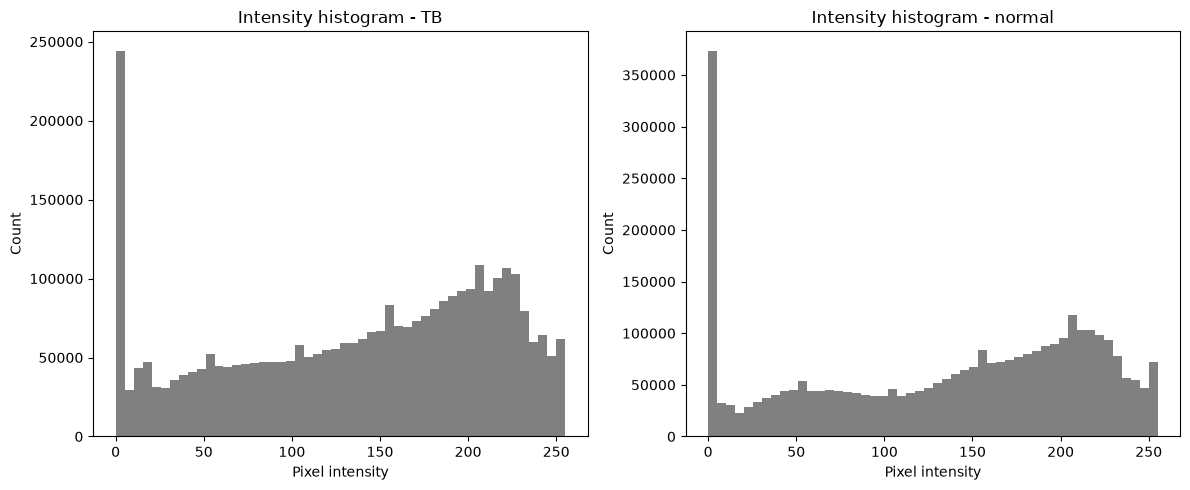

In [3]:
def plot_histograms(df, max_images=50):
    import matplotlib.pyplot as plt
    import numpy as np
    import cv2
    labels = df['label'].unique()
    plt.figure(figsize=(12,5))
    for i, label in enumerate(labels):
        group = df[df['label'] == label]
        sample = group.sample(min(len(group), max_images), random_state=42)
        intensities = np.concatenate([cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), (256, 256)).ravel() for p in sample['path']])
        plt.subplot(1, len(labels), i+1)
        plt.hist(intensities, bins=50, color='gray')
        plt.title(f'Intensity histogram - {label}')
        plt.xlabel('Pixel intensity')
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

plot_histograms(df)

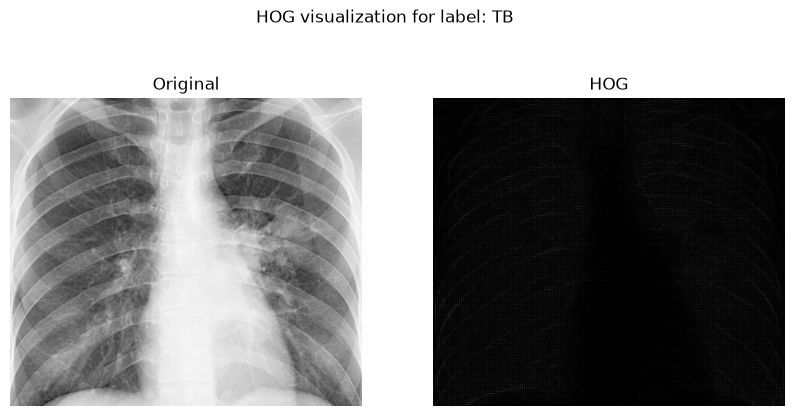

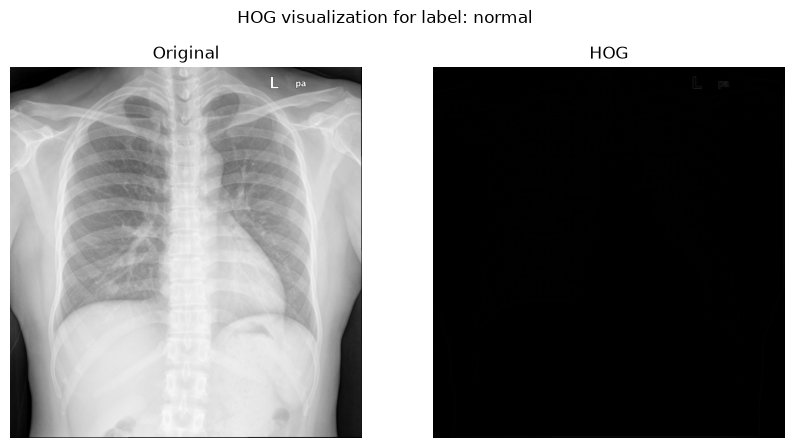

In [4]:
def visualize_hog(df, label, sample_idx=0):
    import cv2
    from skimage.feature import hog
    subset = df[df['label'] == label]
    if subset.empty:
        print(f"No images for label {label}")
        return
    img_path = subset.iloc[sample_idx]['path']
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Cannot read image {img_path}")
        return
    fd, hog_image = hog(img, orientations=9, pixels_per_cell=(8,8),
                        cells_per_block=(2,2), visualize=True, feature_vector=True)
    hog_image_rescaled = (hog_image - hog_image.min()) / (hog_image.max() - hog_image.min())
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
    ax1.imshow(img, cmap='gray')
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(hog_image_rescaled, cmap='gray')
    ax2.set_title('HOG')
    ax2.axis('off')
    plt.suptitle(f'HOG visualization for label: {label}')
    plt.show()

for lbl in df['label'].unique():
    visualize_hog(df, lbl)

In [5]:
from sklearn.model_selection import train_test_split

def split_data(df, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6
    df_train, df_temp = train_test_split(df, train_size=train_size, stratify=df['label'], random_state=random_state)
    val_ratio = val_size / (val_size + test_size)
    df_val, df_test = train_test_split(df_temp, train_size=val_ratio, stratify=df_temp['label'], random_state=random_state)
    return df_train, df_val, df_test

df_train, df_val, df_test = split_data(df)

print("Dataset split counts:")
print("Train:", len(df_train))
print("Validation:", len(df_val))
print("Test:", len(df_test))

print("\nClass distribution per split:")
print("Train:", df_train['label'].value_counts())
print("Validation:", df_val['label'].value_counts())
print("Test:", df_test['label'].value_counts())

Dataset split counts:
Train: 489
Validation: 105
Test: 105

Class distribution per split:
Train: label
normal    255
TB        234
Name: count, dtype: int64
Validation: label
normal    55
TB        50
Name: count, dtype: int64
Test: label
normal    55
TB        50
Name: count, dtype: int64
